<div style="border-left:6px solid #0284c7;background:#f0f9ff;padding:20px 24px;border-radius:10px;color:#0f172a;">
  <div style="color:#0284c7;font-size:12px;font-weight:700;letter-spacing:2px;">PYTORCH LAB · LINEAR CLASSIFICATION</div>
  <h1 style="margin:8px 0;color:#0f172a;">Linear Data Practice</h1>
  <div style="color:#475569;">Linear layers · SGD · Decision boundary</div>
</div>

### 🇬🇧 English

- **Goal:** binary email classification from two numeric scores.
- **Architecture:** two linear layers (`2 → 5 → 1`) without hidden activations, so the boundary remains a straight line.
- **Roadmap:** inspect data → split and create tensors → define logits/loss → train with SGD → plot the analytical decision boundary.
- Run code cells in order from this folder. Saved outputs are retained; explanations describe the existing code, including its limitations.

### 🇹🇷 Türkçe

- **Amaç:** iki sayısal skordan ikili e-posta sınıflandırması.
- **Mimari:** gizli aktivasyon olmadan iki doğrusal katman (`2 → 5 → 1`); karar sınırı doğru olarak kalır.
- **Akış:** veriyi incele → ayır ve tensör oluştur → logits/kaybı tanımla → SGD ile eğit → analitik karar sınırını çiz.
- Kodları bu klasörden sırayla çalıştır. Kayıtlı çıktılar korunur; açıklamalar mevcut kodu ve sınırlarını anlatır.

### 🗺️ Learning path / Öğrenme rotası

| 🔎 Explore / İncele | 🧱 Prepare / Hazırla | 🧠 Build / Kur | ⚙️ Train / Eğit | 📊 Visualize / Görselleştir |
| :--- | :--- | :--- | :--- | :--- |
| CSV & classes | 80/20 · float32 | Linear → Linear | SGD · 100 epochs | Straight boundary |

> 📌 **How to use / Nasıl kullanılır:** Run from top to bottom; each note explains the code below. / Yukarıdan aşağıya çalıştır; her not altındaki kodu açıklar.

---


<div style="border-left:4px solid #0284c7;background:#f0f9ff;padding:12px 16px;border-radius:8px;color:#0f172a;">
  <div style="font-size:11px;font-weight:700;color:#0284c7;letter-spacing:1px;">🧰 SETUP · STEP 01</div>
  <div style="font-size:18px;font-weight:600;margin-top:5px;">Import libraries / Kütüphaneleri içe aktar</div>
</div>

### 🇬🇧 English

PyTorch handles tensors, models, and gradients; Pandas reads tables; NumPy prepares plotting grids; Matplotlib and Seaborn visualize samples and predictions.

### 🇹🇷 Türkçe

PyTorch tensörleri, modelleri ve gradyanları yönetir; Pandas tabloları okur; NumPy çizim ızgaralarını hazırlar; Matplotlib ve Seaborn örnekleri ve tahminleri görselleştirir.


In [1]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

<div style="border-left:4px solid #0284c7;background:#f0f9ff;padding:12px 16px;border-radius:8px;color:#0f172a;">
  <div style="font-size:11px;font-weight:700;color:#0284c7;letter-spacing:1px;">🔎 DATA · STEP 02</div>
  <div style="font-size:18px;font-weight:600;margin-top:5px;">Load email data / E-posta verisini yükle</div>
</div>

### 🇬🇧 English

Read `../data/08-email_classification_svm.csv` into `df`. This local CSV provides two numeric features and the `email_type` target. Despite `svm` in the filename, this notebook trains a PyTorch model, not an SVM. Run from the notebook folder for the relative path to resolve.

### 🇹🇷 Türkçe

`../data/08-email_classification_svm.csv` dosyasını `df` içine oku. Yerel CSV iki sayısal özellik ve `email_type` hedefini sağlar. Dosya adında `svm` geçse de bu notebook SVM değil, PyTorch modeli eğitir. Göreli yol için notebook klasöründen çalıştır.


In [2]:
df = pd.read_csv("../data/08-email_classification_svm.csv")

<div style="border-left:4px solid #0284c7;background:#f0f9ff;padding:12px 16px;border-radius:8px;color:#0f172a;">
  <div style="font-size:11px;font-weight:700;color:#0284c7;letter-spacing:1px;">🔎 DATA · STEP 03</div>
  <div style="font-size:18px;font-weight:600;margin-top:5px;">Inspect schema and missing values / Şemayı ve eksik değerleri incele</div>
</div>

### 🇬🇧 English

`df.info()` reports row counts, column names, non-null counts, and dtypes. The saved output shows 1,000 rows, two float64 feature columns, and one integer target column, with no missing values in these columns.

### 🇹🇷 Türkçe

`df.info()` satır sayısını, sütun adlarını, boş olmayan değer sayılarını ve veri türlerini gösterir. Kayıtlı çıktı 1.000 satır, iki float64 özellik sütunu ve bir tamsayı hedef sütunu gösteriyor; bu sütunlarda eksik değer yok.


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   subject_formality_score    1000 non-null   float64
 1   sender_relationship_score  1000 non-null   float64
 2   email_type                 1000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 23.6 KB


<div style="border-left:4px solid #0284c7;background:#f0f9ff;padding:12px 16px;border-radius:8px;color:#0f172a;">
  <div style="font-size:11px;font-weight:700;color:#0284c7;letter-spacing:1px;">🔎 DATA · STEP 04</div>
  <div style="font-size:18px;font-weight:600;margin-top:5px;">Inspect class labels / Sınıf etiketlerini incele</div>
</div>

### 🇬🇧 English

`unique()` lists the distinct target values. The later binary loss expects labels encoded as 0 and 1; this inspection helps check that assumption. The code does not assign semantic names to those numeric classes.

### 🇹🇷 Türkçe

`unique()`, hedefteki farklı değerleri listeler. Sonraki ikili kayıp fonksiyonu etiketlerin 0 ve 1 olmasını bekler; bu inceleme varsayımı kontrol etmeye yardımcı olur. Kod bu sayısal sınıflara anlamsal isim atamaz.


In [4]:
df["email_type"].unique()

array([0, 1])

<div style="border-left:4px solid #0284c7;background:#f0f9ff;padding:12px 16px;border-radius:8px;color:#0f172a;">
  <div style="font-size:11px;font-weight:700;color:#0284c7;letter-spacing:1px;">🔎 DATA · STEP 05</div>
  <div style="font-size:18px;font-weight:600;margin-top:5px;">Visualize feature space / Özellik uzayını görselleştir</div>
</div>

### 🇬🇧 English

Plot subject formality against sender relationship, coloring points by `email_type`. Inspect whether one straight line could separate the classes. This plot is exploratory; it does not fit a model.

### 🇹🇷 Türkçe

Konu resmiyeti ile gönderen ilişki skorunu çiz; noktaları `email_type` değerine göre renklendir. Sınıfların tek bir doğruyla ayrılıp ayrılamayacağını incele. Bu keşif grafiği model eğitmez.


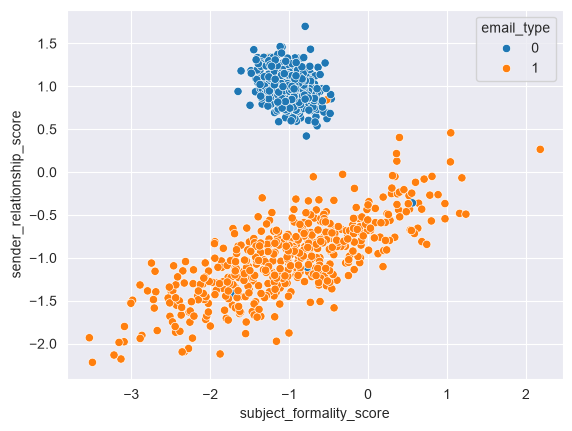

In [5]:
sns.scatterplot(x=df["subject_formality_score"], y=df["sender_relationship_score"], hue=df["email_type"])
plt.show()

<div style="border-left:4px solid #0284c7;background:#f0f9ff;padding:12px 16px;border-radius:8px;color:#0f172a;">
  <div style="font-size:11px;font-weight:700;color:#0284c7;letter-spacing:1px;">🧱 PREPARATION · STEP 06</div>
  <div style="font-size:18px;font-weight:600;margin-top:5px;">Select inputs and target / Girdileri ve hedefi seç</div>
</div>

### 🇬🇧 English

Select two feature columns in a fixed order and convert them to an `(N, 2)` NumPy array with `.values`. The target becomes a one-dimensional `(N,)` array. Keep this feature order consistent when predicting new samples.

### 🇹🇷 Türkçe

İki özellik sütununu sabit sırayla seç ve `.values` ile `(N, 2)` NumPy dizisine çevir. Hedef, `(N,)` şeklinde tek boyutlu dizi olur. Yeni örneklerde tahmin yaparken özellik sırasını aynı tut.


In [6]:
X = df[["subject_formality_score", "sender_relationship_score"]].values
y = df["email_type"].values

<div style="border-left:4px solid #0284c7;background:#f0f9ff;padding:12px 16px;border-radius:8px;color:#0f172a;">
  <div style="font-size:11px;font-weight:700;color:#0284c7;letter-spacing:1px;">🧱 PREPARATION · STEP 07</div>
  <div style="font-size:18px;font-weight:600;margin-top:5px;">Inspect the input array / Girdi dizisini incele</div>
</div>

### 🇬🇧 English

Display `X`: each row contains the two scores for one email. Displaying the array does not normalize, shuffle, or change its values.

### 🇹🇷 Türkçe

`X` dizisini göster: her satır bir e-postanın iki skorunu içerir. Diziyi göstermek değerleri normalize etmez, karıştırmaz veya değiştirmez.


In [7]:
X

array([[-1.49678965,  0.77925822],
       [-1.21760978,  0.88960104],
       [-0.37594518, -0.82332435],
       ...,
       [-1.36975007,  1.0222785 ],
       [-1.1850392 , -1.20266647],
       [-1.17835511,  1.08298346]], shape=(1000, 2))

<div style="border-left:4px solid #0284c7;background:#f0f9ff;padding:12px 16px;border-radius:8px;color:#0f172a;">
  <div style="font-size:11px;font-weight:700;color:#0284c7;letter-spacing:1px;">🧱 PREPARATION · STEP 08</div>
  <div style="font-size:18px;font-weight:600;margin-top:5px;">Import the split helper / Ayırma aracını içe aktar</div>
</div>

### 🇬🇧 English

`train_test_split` from Scikit-Learn separates aligned inputs and targets into training and test subsets.

### 🇹🇷 Türkçe

Scikit-Learn içindeki `train_test_split`, eşleşen girdi ve hedefleri eğitim ve test alt kümelerine ayırır.


In [8]:
from sklearn.model_selection import train_test_split

<div style="border-left:4px solid #0284c7;background:#f0f9ff;padding:12px 16px;border-radius:8px;color:#0f172a;">
  <div style="font-size:11px;font-weight:700;color:#0284c7;letter-spacing:1px;">🧱 PREPARATION · STEP 09</div>
  <div style="font-size:18px;font-weight:600;margin-top:5px;">Create a reproducible split / Tekrarlanabilir veri ayrımı oluştur</div>
</div>

### 🇬🇧 English

`test_size=0.2` reserves 20% for testing and 80% for training. The default behavior shuffles rows; `random_state=42` fixes this split. No `stratify` argument is supplied, so class proportions are not explicitly preserved. This seed does not control PyTorch model initialization.

### 🇹🇷 Türkçe

`test_size=0.2`, verinin %20’sini test ve %80’ini eğitim için ayırır. Varsayılan davranış satırları karıştırır; `random_state=42` bu ayrımı sabitler. `stratify` verilmediği için sınıf oranları özellikle korunmaz. Bu tohum PyTorch modelinin başlangıç parametrelerini kontrol etmez.


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

<div style="border-left:4px solid #0284c7;background:#f0f9ff;padding:12px 16px;border-radius:8px;color:#0f172a;">
  <div style="font-size:11px;font-weight:700;color:#0284c7;letter-spacing:1px;">🧱 PREPARATION · STEP 10</div>
  <div style="font-size:18px;font-weight:600;margin-top:5px;">Convert to float32 tensors / float32 tensörlere dönüştür</div>
</div>

### 🇬🇧 English

Convert all subsets to float32 for the model and binary loss. Inputs keep shape `(N, 2)`. `unsqueeze(1)` changes targets from `(N,)` to `(N, 1)`, matching the single output logit per sample. The labels still represent 0 or 1 even though stored as floats.

### 🇹🇷 Türkçe

Model ve ikili kayıp için tüm alt kümeleri float32 yap. Girdiler `(N, 2)` şeklini korur. `unsqueeze(1)`, hedefleri `(N,)` şeklinden `(N, 1)` şekline getirerek örnek başına tek çıktı logitiyle eşleştirir. Etiketler float olarak saklansa da 0 veya 1’i temsil eder.


In [10]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

<div style="border-left:4px solid #0284c7;background:#f0f9ff;padding:12px 16px;border-radius:8px;color:#0f172a;">
  <div style="font-size:11px;font-weight:700;color:#0284c7;letter-spacing:1px;">🧱 PREPARATION · STEP 11</div>
  <div style="font-size:18px;font-weight:600;margin-top:5px;">Verify tensor shapes / Tensör şekillerini doğrula</div>
</div>

### 🇬🇧 English

Print train/test input and target shapes. The saved output shows `(800, 2)` and `(800, 1)` for training, `(200, 2)` and `(200, 1)` for testing. Matching sample counts prevent input/target alignment errors.

### 🇹🇷 Türkçe

Eğitim/test girdi ve hedef şekillerini yazdır. Kayıtlı çıktı eğitimde `(800, 2)` ve `(800, 1)`, testte `(200, 2)` ve `(200, 1)` gösteriyor. Örnek sayılarının eşleşmesi girdi/hedef uyumsuzluğunu önler.


In [11]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

torch.Size([800, 2]) torch.Size([800, 1])
torch.Size([200, 2]) torch.Size([200, 1])


<div style="border-left:4px solid #0284c7;background:#f0f9ff;padding:12px 16px;border-radius:8px;color:#0f172a;">
  <div style="font-size:11px;font-weight:700;color:#0284c7;letter-spacing:1px;">🧠 MODEL · STEP 12</div>
  <div style="font-size:18px;font-weight:600;margin-top:5px;">Define a linear classifier / Doğrusal sınıflandırıcıyı tanımla</div>
</div>

### 🇬🇧 English

Subclass `nn.Module` and initialize its base class. `layer1` maps two features to five values; `layer2` maps those five values to one raw logit. There is no activation between layers, so the composition is still affine: `W_eff = W2 @ W1` and `b_eff = W2 @ b1 + b2`. Increasing this hidden width alone cannot create a curved decision boundary.

### 🇹🇷 Türkçe

`nn.Module` sınıfından türe ve temel sınıfı başlat. `layer1` iki özelliği beş değere, `layer2` bu beş değeri tek ham logite dönüştürür. Katmanlar arasında aktivasyon yoktur; bileşim hâlâ afin dönüşümdür: `W_eff = W2 @ W1`, `b_eff = W2 @ b1 + b2`. Sadece gizli katmanı genişletmek eğri karar sınırı oluşturamaz.


In [12]:
from torch import nn

class ClassificationModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.layer1 = nn.Linear(in_features=2, out_features=5)
        self.layer2 = nn.Linear(in_features=5, out_features=1)

    def forward(self, x):
        return self.layer2(self.layer1(x))

<div style="border-left:4px solid #0284c7;background:#f0f9ff;padding:12px 16px;border-radius:8px;color:#0f172a;">
  <div style="font-size:11px;font-weight:700;color:#0284c7;letter-spacing:1px;">🧠 MODEL · STEP 13</div>
  <div style="font-size:18px;font-weight:600;margin-top:5px;">Instantiate the model / Model örneğini oluştur</div>
</div>

### 🇬🇧 English

Create `model_0` and its random layer weights and biases. The notebook sets `torch.manual_seed(42)` later, after this initialization, so that later seed does not make these initial values reproducible on its own.

### 🇹🇷 Türkçe

`model_0` nesnesini ve katmanlarının rastgele ağırlık/bias değerlerini oluştur. Notebook `torch.manual_seed(42)` çağrısını daha sonra, bu başlangıçtan sonra yapıyor; sonraki tohum tek başına bu başlangıç değerlerini tekrarlanabilir yapmaz.


In [13]:
model_0 = ClassificationModel()

<div style="border-left:4px solid #0284c7;background:#f0f9ff;padding:12px 16px;border-radius:8px;color:#0f172a;">
  <div style="font-size:11px;font-weight:700;color:#0284c7;letter-spacing:1px;">⚙️ TRAINING · STEP 14</div>
  <div style="font-size:18px;font-weight:600;margin-top:5px;">Configure binary loss and SGD / İkili kaybı ve SGD’yi ayarla</div>
</div>

### 🇬🇧 English

`BCEWithLogitsLoss` combines sigmoid and binary cross-entropy in a numerically stable calculation. Pass raw logits to it, not rounded labels or sigmoid probabilities. SGD updates registered parameters with learning rate `0.01`.

### 🇹🇷 Türkçe

`BCEWithLogitsLoss`, sigmoid ve ikili çapraz entropiyi sayısal olarak kararlı bir hesapta birleştirir. Bu fonksiyona yuvarlanmış etiketler veya sigmoid olasılıkları değil, ham logits ver. SGD kayıtlı parametreleri `0.01` öğrenme oranıyla günceller.


In [14]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model_0.parameters(), lr=0.01)

<div style="border-left:4px solid #0284c7;background:#f0f9ff;padding:12px 16px;border-radius:8px;color:#0f172a;">
  <div style="font-size:11px;font-weight:700;color:#0284c7;letter-spacing:1px;">⚙️ TRAINING · STEP 15</div>
  <div style="font-size:18px;font-weight:600;margin-top:5px;">Define binary accuracy / İkili sınıflandırma doğruluğunu tanımla</div>
</div>

### 🇬🇧 English

`torch.eq` compares predicted and true labels element by element. Sum the matches, convert the scalar with `.item()`, divide by the sample count, and multiply by 100. The result is a percentage. Both tensors must have matching `(N, 1)` shapes; mismatched shapes could broadcast and produce an incorrect count.

### 🇹🇷 Türkçe

`torch.eq`, tahmini ve gerçek etiketleri eleman bazında karşılaştırır. Eşleşmeleri topla, `.item()` ile skaler değeri al, örnek sayısına böl ve 100 ile çarp. Sonuç yüzdedir. İki tensörün şekli de `(N, 1)` olmalı; farklı şekiller broadcasting nedeniyle yanlış sayım üretebilir.


In [16]:
def calculate_accuracy(y_pred, y_test):
    correct = torch.eq(y_pred, y_test).sum().item()
    accuracy = (correct / len(y_pred)) * 100
    return accuracy

<div style="border-left:4px solid #0284c7;background:#f0f9ff;padding:12px 16px;border-radius:8px;color:#0f172a;">
  <div style="font-size:11px;font-weight:700;color:#0284c7;letter-spacing:1px;">⚙️ TRAINING · STEP 16</div>
  <div style="font-size:18px;font-weight:600;margin-top:5px;">Train and evaluate / Eğit ve değerlendir</div>
</div>

### 🇬🇧 English

Run 100 full-batch epochs. The seed is set here, but the existing model is not reinitialized.

1. `train()` selects training mode.
2. The forward pass produces raw logits. `sigmoid` maps them to probabilities; `round` produces labels for accuracy (with PyTorch rounding exactly 0.5 to 0).
3. Compute binary loss from **logits** and accuracy from **labels**. The rounded predictions do not drive backpropagation.
4. Clear old gradients with `zero_grad()`, compute new ones with `backward()`, and update parameters with `step()`.
5. Switch to `eval()` and disable gradient tracking with `inference_mode()` for test loss and accuracy.
6. Print metrics every five epochs. Training metrics are from before the update; test metrics are from after it.

Repeatedly inspecting test metrics is useful in this exercise; use a separate validation set for tuning and reserve a final test set when assessing generalization.

### 🇹🇷 Türkçe

100 full-batch epoch çalıştır. Tohum burada ayarlanır ancak mevcut model yeniden başlatılmaz.

1. `train()` eğitim modunu seçer.
2. İleri yayılım ham logits üretir. `sigmoid` bunları olasılığa, `round` doğruluk için etikete çevirir (PyTorch tam 0.5 değerini 0’a yuvarlar).
3. İkili kaybı **logits** ile, doğruluğu **etiketler** ile hesapla. Yuvarlanmış tahminler geri yayılımı yönetmez.
4. `zero_grad()` ile eski gradyanları temizle, `backward()` ile yenilerini hesapla, `step()` ile parametreleri güncelle.
5. Test kaybı ve doğruluğu için `eval()` moduna geç ve `inference_mode()` ile gradyan takibini kapat.
6. Her beş epoch’ta metrikleri yazdır. Eğitim metrikleri güncellemeden önce, test metrikleri sonra hesaplanır.

Bu alıştırmada test metriklerini tekrar incelemek öğreticidir; genellemeyi değerlendirirken ayarlar için ayrı doğrulama kümesi kullanıp son test kümesini sona sakla.


In [17]:
torch.manual_seed(42)
epochs = 100

for epoch in range(epochs):

    model_0.train()

    y_logits = model_0(X_train)
    y_pred = torch.round(torch.sigmoid(y_logits))

    loss = loss_fn(y_logits, y_train)
    acc = calculate_accuracy(y_test = y_train, y_pred = y_pred)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_0.eval()
    with torch.inference_mode():
        test_logits = model_0(X_test)
        test_pred = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_fn(test_logits, y_test)
        test_acc = calculate_accuracy(y_pred = test_pred, y_test = y_test)

        if epoch % 5 == 0:
            print(f"Epoch: {epoch}, Loss: {loss}, Accuracy: {acc}, Test Loss: {test_loss}, Test Accuracy: {test_acc}")

Epoch: 0, Loss: 0.6339756846427917, Accuracy: 49.75, Test Loss: 0.6165609955787659, Test Accuracy: 52.0
Epoch: 5, Loss: 0.6170945763587952, Accuracy: 49.75, Test Loss: 0.5997763872146606, Test Accuracy: 52.0
Epoch: 10, Loss: 0.6007305383682251, Accuracy: 49.75, Test Loss: 0.5835056304931641, Test Accuracy: 52.0
Epoch: 15, Loss: 0.5848475098609924, Accuracy: 50.375, Test Loss: 0.5677138566970825, Test Accuracy: 52.0
Epoch: 20, Loss: 0.569415271282196, Accuracy: 51.0, Test Loss: 0.5523719191551208, Test Accuracy: 52.0
Epoch: 25, Loss: 0.5544084310531616, Accuracy: 53.25, Test Loss: 0.537455677986145, Test Accuracy: 52.5
Epoch: 30, Loss: 0.5398059487342834, Accuracy: 56.00000000000001, Test Loss: 0.5229448080062866, Test Accuracy: 56.99999999999999
Epoch: 35, Loss: 0.5255905985832214, Accuracy: 59.5, Test Loss: 0.5088230967521667, Test Accuracy: 63.0
Epoch: 40, Loss: 0.5117482542991638, Accuracy: 63.375, Test Loss: 0.495076984167099, Test Accuracy: 68.5
Epoch: 45, Loss: 0.4982675909996032

<div style="border-left:4px solid #0284c7;background:#f0f9ff;padding:12px 16px;border-radius:8px;color:#0f172a;">
  <div style="font-size:11px;font-weight:700;color:#0284c7;letter-spacing:1px;">📊 VISUALIZATION · STEP 17</div>
  <div style="font-size:18px;font-weight:600;margin-top:5px;">Derive the straight decision boundary / Doğru karar sınırını türet</div>
</div>

### 🇬🇧 English

Detach CPU parameters and convert them to NumPy. Combine both layers into `W_eff` and `b_eff`. The probability-0.5 boundary occurs at logit zero: `w1*x1 + w2*x2 + b_eff = 0`. Solve for `x2` and plot the resulting line over the labeled points. This formula divides by `w2`; a zero or nearly zero value requires special handling for a vertical or unstable line. `.numpy()` also assumes CPU tensors.

### 🇹🇷 Türkçe

CPU parametrelerini gradyan takibinden ayır ve NumPy’a dönüştür. İki katmanı `W_eff` ve `b_eff` içinde birleştir. Olasılığın 0.5 olduğu sınır logitin sıfır olduğu yerdir: `w1*x1 + w2*x2 + b_eff = 0`. `x2` için çöz ve doğruyu etiketli noktaların üzerine çiz. Formül `w2` değerine böler; sıfır veya çok küçük değer dikey ya da kararsız doğru için özel işlem gerektirir. `.numpy()` de CPU tensörlerini varsayar.


In [20]:
def plot_linear_decision_boundary(model, X, y):

    # layer_1: (5,2)
    # layer_2: (1,5)
    # toplam efektif ağırlık = layer_2.weight @ layer_1.weight = (1,2)
    W1 = model.layer1.weight.detach().numpy()       # shape (5,2)
    b1 = model.layer1.bias.detach().numpy()         # shape (5,)
    W2 = model.layer2.weight.detach().numpy()       # shape (1,5)
    b2 = model.layer2.bias.detach().numpy()[0]      # shape (1,)

    # efektif W ve b
    # W_eff = W2 * W1
    W_eff = W2 @ W1   # shape (1,2)
    w1, w2 = W_eff[0] # iki feature'ın ağırlığı

    # efektif b = W2 * b1 + b2
    b_eff = (W2 @ b1)[0] + b2

    # X aralığı
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    xs = np.linspace(x_min, x_max, 200)

    # Doğru denkleminden x2 hesaplama
    # w1*x1 + w2*x2 + b = 0  →  x2 = -(w1*x1 + b) / w2
    ys = -(w1 * xs + b_eff) / w2

    # Noktalar
    plt.scatter(X[:, 0], X[:, 1], c=y.squeeze(), cmap=plt.cm.RdYlBu, s=40)
    plt.plot(xs, ys, "k-", linewidth=3)
    plt.xlabel("subject_formality_score")
    plt.ylabel("sender_relationship_score")
    plt.xlim(x_min, x_max)
    plt.ylim(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5)

<div style="border-left:4px solid #0284c7;background:#f0f9ff;padding:12px 16px;border-radius:8px;color:#0f172a;">
  <div style="font-size:11px;font-weight:700;color:#0284c7;letter-spacing:1px;">📊 VISUALIZATION · STEP 18</div>
  <div style="font-size:18px;font-weight:600;margin-top:5px;">Compare train and test boundaries / Eğitim ve test sınırlarını karşılaştır</div>
</div>

### 🇬🇧 English

Create a two-panel figure and draw the same trained classifier over each subset. The left panel shows training samples, the right test samples. The model is unchanged between panels; sample locations and axis ranges can differ.

### 🇹🇷 Türkçe

İki panelli grafik oluştur ve aynı eğitilmiş sınıflandırıcıyı her alt küme üzerinde çiz. Solda eğitim, sağda test örnekleri vardır. Paneller arasında model değişmez; örnek konumları ve eksen aralıkları farklı olabilir.


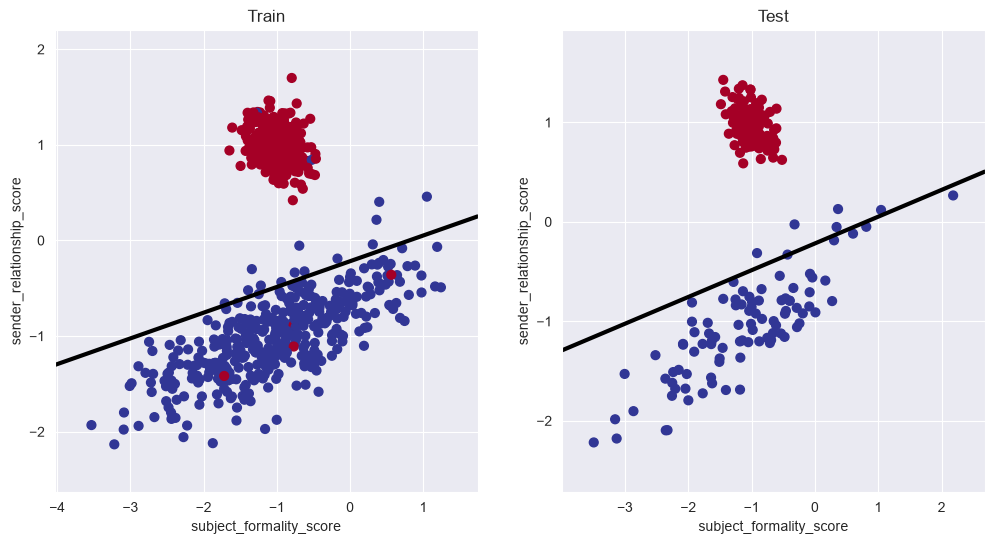

In [21]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Train")
plot_linear_decision_boundary(model_0, X_train, y_train)

plt.subplot(1, 2, 2)
plt.title("Test")
plot_linear_decision_boundary(model_0, X_test, y_test)

plt.show()